5장 시계열 예측

In [ ]:
# 예제 5.2 온도 예측

from google.colab import drive
drive.mount("/content/drive")

In [2]:
# 셋업
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.utils import timeseries_dataset_from_array
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# 데이터셋 준비
df = pd.read_csv("/content/drive/MyDrive/Datasets/weather.csv")

print(df.shape)   # 데이터셋 shape 확인
print(df.columns)   # 컬럼명 확인

(26304, 6)
Index(['일시', '기온(°C)', '풍속(m/s)', '풍향(16방위)', '습도(%)', '현지기압(hPa)'], dtype='object')


In [4]:
# 상위 데이터 출력
df.head()

,일시,기온(°C),풍속(m/s),풍향(16방위),습도(%),현지기압(hPa)
0,2020-01-01 00:00,-6.5,0.0,0.0,38,1022.6
1,2020-01-01 01:00,-5.9,1.7,50.0,40,1021.8
2,2020-01-01 02:00,-5.7,0.1,0.0,42,1021.6
3,2020-01-01 03:00,-5.6,0.0,0.0,46,1021.5
4,2020-01-01 04:00,-5.4,0.0,0.0,50,1021.6


In [5]:
# 불필요한 컬럼 제거
df = df.drop(["일시"], axis=1)

In [6]:
# 통계 요약
df.describe().loc[["count", "mean", "std", "min", "max"]].round(2)

,기온(°C),풍속(m/s),풍향(16방위),습도(%),현지기압(hPa)
count,26303.00,26302.00,26302.00,26304.00,26291.00
mean,13.43,2.35,185.35,64.45,1006.10
std,10.78,1.16,107.83,19.03,8.21
min,-18.50,0.00,0.00,11.00,975.20
max,36.30,8.80,360.00,100.00,1027.20


In [7]:
# 결측치 있는 행 삭제
df = df.dropna()

In [8]:
# 정규화
min = df.min()
max = df.max()

weather_df = (df - min) / (max - min)

In [9]:
# 시퀀스 데이터셋 준비
num_train = int(0.8 * len(weather_df))   # 학습/검증/테스트 데이터 분할
num_valid = int(0.1 * len(weather_df))
num_test = len(weather_df) - num_train - num_valid

sequence_length = 24 * 3   # 3일간의 데이터 입력
offset = 24   # 1일 후 온도 예측
shift = sequence_length + offset - 1   # 레이블 위치

train_ds = timeseries_dataset_from_array(   # 학습 데이터셋
    data=weather_df.to_numpy()[:-shift],   # 입력
    targets=df["기온(°C)"].to_numpy()[shift:], # 레이블
    sequence_length=sequence_length,   # 시퀀스 길이
    batch_size=32,   # 배치 크기 32
    shuffle=False,   # 셔플링하지 않음
    start_index=0,   # 시퀀스 시작
    end_index=num_train)   # 시퀀스 끝

valid_ds = timeseries_dataset_from_array(   # 검증 데이터셋
    data=weather_df.to_numpy()[:-shift],
    targets=df["기온(°C)"].to_numpy()[shift:],
    sequence_length=sequence_length,
    batch_size=32,
    shuffle=False,
    start_index=num_train,
    end_index=num_train + num_valid)

test_ds = timeseries_dataset_from_array(   # 테스트 데이터셋
    data=weather_df.to_numpy()[:-shift],
    targets=df["기온(°C)"].to_numpy()[shift:],
    sequence_length=sequence_length,
    batch_size=32,
    shuffle=False,
    start_index=num_train + num_valid)

In [10]:
# 모델 생성
inputs = Input(shape=(sequence_length, 5))   # 입력 특징 5개
x = GRU(16, return_sequences=True)(inputs)   # 뉴런 수 16개, 출력 전체 시퀀스 반환
x = GRU(16)(x)   # 뉴런 수 16개
x = Dropout(0.5)(x)   # 드롭아웃 확률 0.5
outputs = Dense(1)(x)   # 출력층 뉴런 1개

model = Model(inputs, outputs)

In [11]:
# 모델 컴파일
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

In [ ]:
# 모델 학습
history = model.fit(train_ds, epochs=20, verbose=0, validation_data=valid_ds)

77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


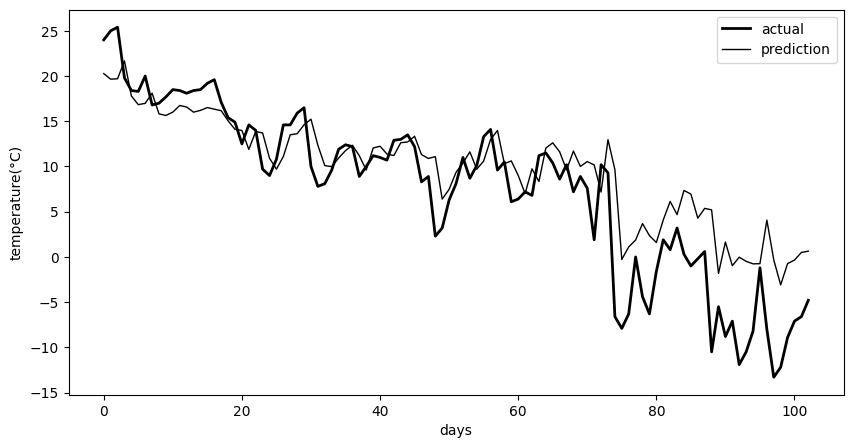

In [13]:
# 예측 결과 시각화
y_pred = model.predict(test_ds)

y_test = []
for _, targets in test_ds:
    y_test.extend(targets)

plt.figure(figsize=(10, 5))

plt.plot(y_test[::24], label="actual", color="black", linewidth=2)   # 24시간 간격
plt.plot(y_pred[::24], label="prediction", color="black", linewidth=1)
plt.xlabel("days")
plt.ylabel("temperature(°C)")
plt.legend(loc="best")

plt.show()

In [ ]:
# 예제 5.3 주가 예측

# finance-datareader 설치
!pip install finance-datareader

In [ ]:
# 셋업
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.utils import timeseries_dataset_from_array
import FinanceDataReader as fdr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# 데이터셋 준비
df = fdr.DataReader("005930", "2020-01-01", "2025-12-31")

In [ ]:
# 상위 데이터 확인
df.head()

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2020-01-02,55500,56000,55000,55200,12993228,-0.010753
2020-01-03,56000,56600,54900,55500,15422255,0.005435
2020-01-06,54900,55600,54600,55500,10278951,0.000000
2020-01-07,55700,56400,55600,55800,10009778,0.005405
2020-01-08,56200,57400,55900,56800,23501171,0.017921


In [ ]:
# 불필요한 컬럼 제거
df = df.drop("Change", axis=1)

In [ ]:
# 정규화
min = df.min()
max = df.max()

stock_df = (df - min) / (max - min)

In [ ]:
# 시퀀스 데이터셋 준비
sequence_length = 3   # 3일간의 데이터 입력
offset = 1   # 다음 날 주가 예측
shift = sequence_length + offset - 1   # 레이블 위치

train_ds = timeseries_dataset_from_array(   # 학습 데이터셋
    data=stock_df["2020-01":"2023-12"].to_numpy()[:-shift],
    targets=stock_df["Close"]["2020-01":"2023-12"].to_numpy()[shift:],
    sequence_length=sequence_length,
    batch_size=32,
    shuffle=False)

valid_ds = timeseries_dataset_from_array(   # 검증 데이터셋
    data=stock_df["2024-01":"2024-12"].to_numpy()[:-shift],
    targets=stock_df["Close"]["2024-01":"2024-12"].to_numpy()[shift:],
    sequence_length=sequence_length,
    batch_size=32,
    shuffle=False)

test_ds = timeseries_dataset_from_array(   # 테스트 데이터셋
    data=stock_df["2025-01":"2025-12"].to_numpy()[:-shift],
    targets=stock_df["Close"]["2025-01":"2025-12"].to_numpy()[shift:],
    sequence_length=sequence_length,
    batch_size=32,
    shuffle=False)

In [ ]:
# 모델 생성
inputs = Input(shape=(sequence_length, 5))   # 입력 특징 5개
x = LSTM(8, return_sequences=True)(inputs)   # 뉴런 수 8개, 출력 전체 시퀀스 반환
x = LSTM(8)(x)   # 뉴런 수 8개
outputs = Dense(1)(x)   # 출력층 뉴런 1개

model = Model(inputs, outputs)

In [ ]:
# 모델 컴파일
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

In [ ]:
# 모델 학습
history = model.fit(train_ds, epochs=20, verbose=0, validation_data=valid_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


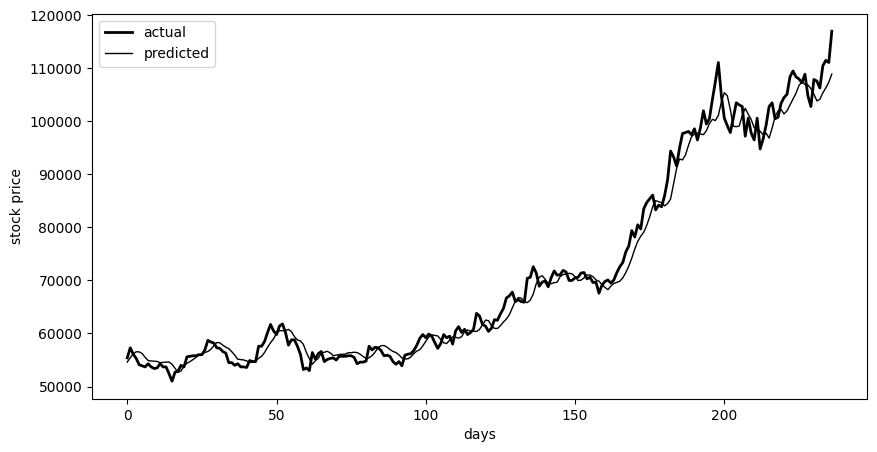

In [ ]:
# 예측 결과 시각화
max_C = df["Close"].max()   # 종가의 최대값
min_C = df["Close"].min()   # 종가의 최소값

y_pred = model.predict(test_ds)
y_pred = y_pred * (max_C - min_C) + min_C

y_test = []
for _, targets in test_ds:
    y_test.extend(targets)
y_test = np.array(y_test) * (max_C - min_C) + min_C

plt.figure(figsize=(10, 5))

plt.plot(y_test, label="actual", color="black", linewidth=2)
plt.plot(y_pred, label="predicted", color="black", linewidth=1)
plt.xlabel("days")
plt.ylabel("stock price")
plt.legend()

plt.show()